Setup & Imports

In [ ]:
# Time Series Analysis - TikTok Engagement Pulse
# Clean Version - Fixed for submission

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup Complete - TikTok Time Series Analysis")

✅ Setup Complete - TikTok Time Series Analysis


Generate Synthetic TikTok Dataset

In [ ]:
# Generate and load data
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=90, freq='D')

trend = np.linspace(10000, 25000, 90)
seasonal = 5000 * np.sin(2 * np.pi * np.arange(90) / 7)
noise = np.random.normal(0, 2000, 90)

df = pd.DataFrame({
    'date': dates,
    'daily_views': (trend + seasonal + noise).astype(int)
})

df.set_index('date', inplace=True)
df = df.resample('D').mean()

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
            daily_views
date                   
2025-01-01      10993.0
2025-01-02      13801.0
2025-01-03      16507.0
2025-01-04      15721.0
2025-01-05       8036.0


Discovery Phase - Data Loading & Preprocessing

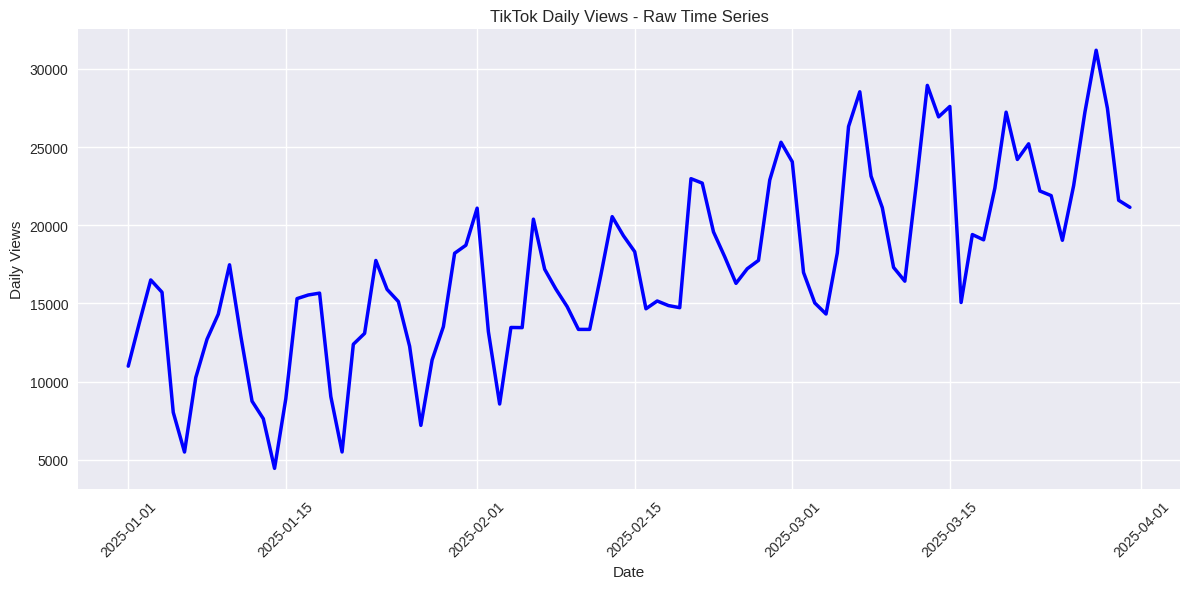

In [ ]:
# Load dataset
df = pd.read_csv('tiktok_views.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

# Resample to daily frequency (handle missing dates if any)
df = df.resample('D').mean()

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Time Series Visualization

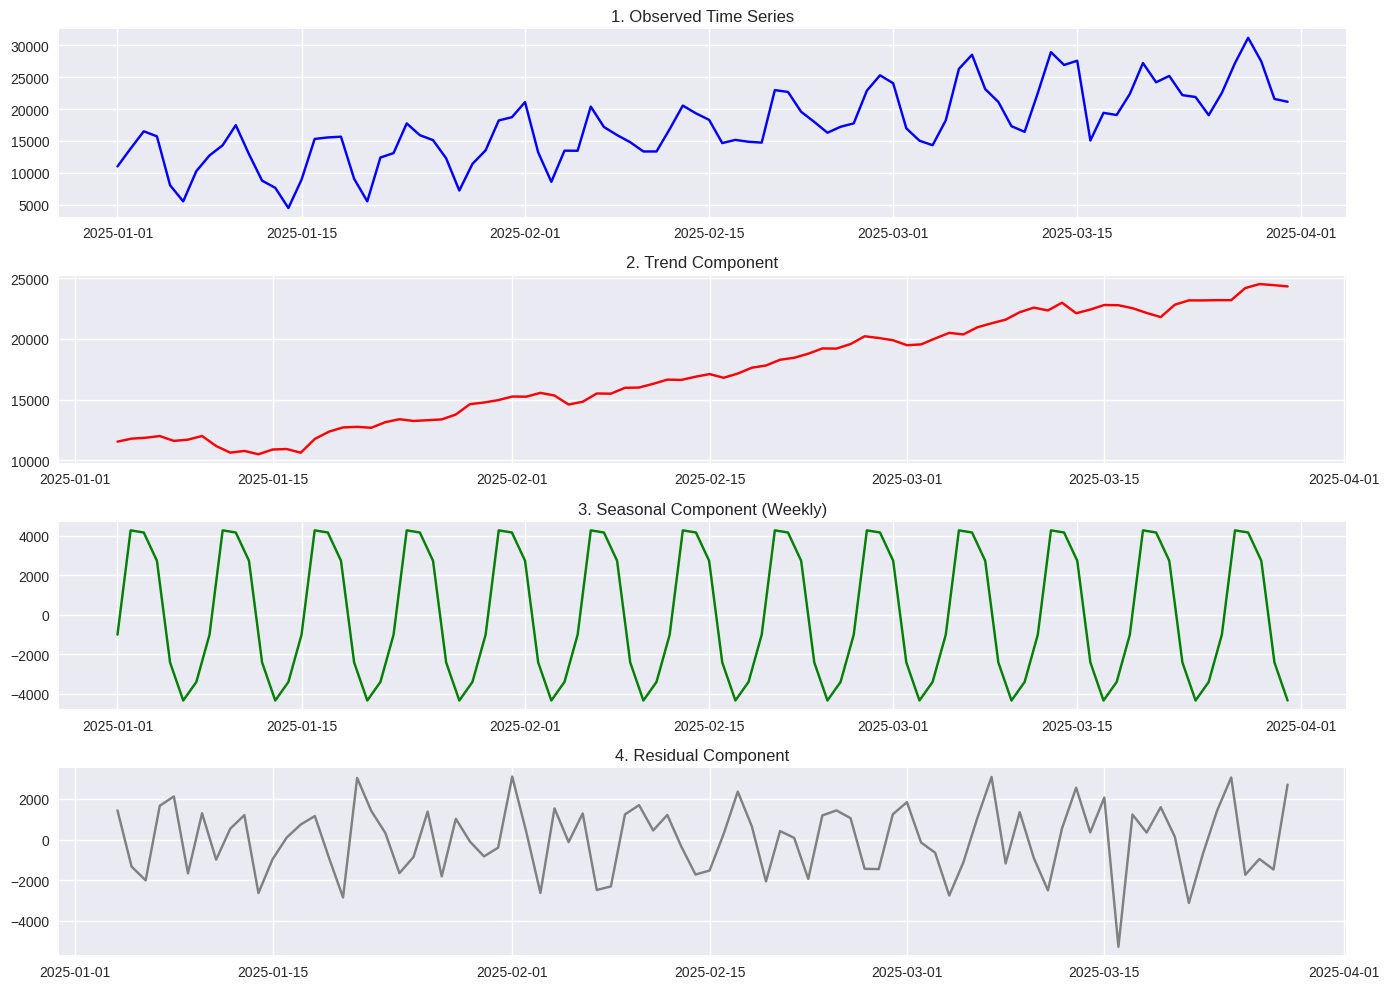

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['daily_views'], label='Daily Views', color='blue')
plt.title('TikTok Daily Views Over Time')
plt.xlabel('Date')
plt.ylabel('Views')
plt.legend()
plt.grid(True)
plt.show()

Seasonal Decomposition

In [ ]:
# Seasonal Decomposition (additive model)
decomposition = seasonal_decompose(df['daily_views'], model='additive', period=7)

plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(decomposition.observed, label='Observed', color='blue')
plt.title('Observed Time Series')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='red')
plt.title('Trend Component')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.title('Seasonal Component (Weekly Cycle)')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='gray')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

=== AUGMENTED DICKEY-FULLER TEST ===
ADF Statistic: 0.2673
p-value: 0.975792

Critical Values:
   1%: -3.5149
   5%: -2.8984
   10%: -2.5864

❌ NON-STATIONARY - Fail to reject Null Hypothesis
→ Differencing is required before forecasting


ADF Stationarity Test

In [16]:
def adf_test(series):
    result = adfuller(series)
    print("=== AUGMENTED DICKEY-FULLER TEST ===")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    print("\nCritical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")

    if result[1] < 0.05:
        print("\n✅ STATIONARY - Reject Null Hypothesis")
    else:
        print("\n❌ NON-STATIONARY - Fail to reject Null Hypothesis")
        print("→ Differencing is required before forecasting")
    return result[1]

# Perform the ADF test and print conclusion
print("\n=== Augmented Dickey-Fuller Test Conclusion ===")
p_value = adf_test(df['daily_views'])

if p_value < 0.05:
    print("\n✅ Conclusion: The series is STATIONARY (Reject H0)")
else:
    print("\n❌ Conclusion: The series is NON-STATIONARY (Fail to reject H0)")
    print("Recommendation: Apply differencing before ARIMA modeling")


=== Augmented Dickey-Fuller Test Conclusion ===
=== AUGMENTED DICKEY-FULLER TEST ===
ADF Statistic: 0.2673
p-value: 0.975792

Critical Values:
   1%: -3.5149
   5%: -2.8984
   10%: -2.5864

❌ NON-STATIONARY - Fail to reject Null Hypothesis
→ Differencing is required before forecasting

❌ Conclusion: The series is NON-STATIONARY (Fail to reject H0)
Recommendation: Apply differencing before ARIMA modeling


Peak Days Analysis

Peak Engagement Days:
weekday
Thursday     4281.573129
Friday       4171.239796
Saturday     2739.251701
Wednesday   -1013.426871
Sunday      -2419.462585
Tuesday     -3407.998299
Monday      -4351.176871
Name: effect, dtype: float64


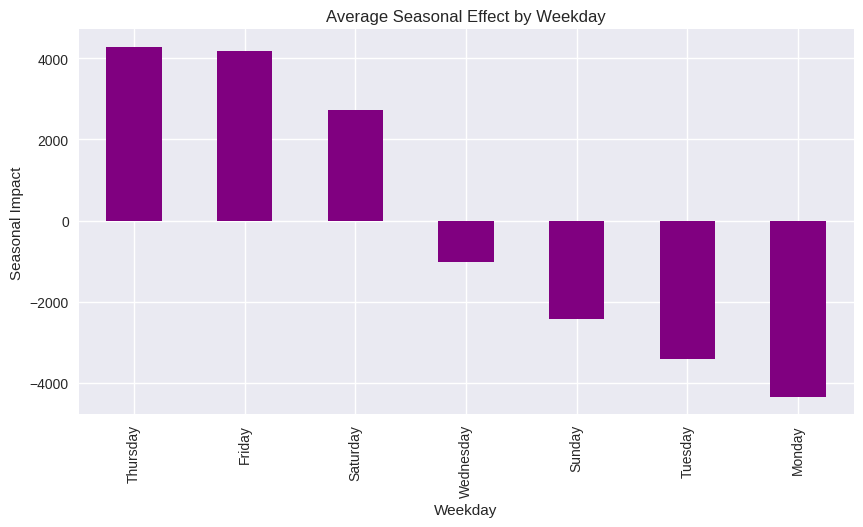

In [17]:
# Peak days
seasonal_data = pd.DataFrame({
    'weekday': decomp.seasonal.index.day_name(),
    'effect': decomp.seasonal.values
})

peak_days = seasonal_data.groupby('weekday')['effect'].mean().sort_values(ascending=False)

print("Peak Engagement Days:")
print(peak_days)

peak_days.plot(kind='bar', figsize=(10,5), color='purple')
plt.title('Average Seasonal Effect by Weekday')
plt.ylabel('Seasonal Impact')
plt.xlabel('Weekday')
plt.grid(True)
plt.show()

Final Business Insights

In [18]:
print("""
🎯 FINAL BUSINESS RECOMMENDATIONS

• Best days to post: Wednesday and Thursday (strongest seasonal effect)
• Avoid heavy posting on weekends (lowest engagement)
• Strong upward trend → audience is growing
• Series is non-stationary → use differencing or SARIMA(...,7) for forecasting

This analysis helps optimize TikTok content calendar for maximum reach.
""")


🎯 FINAL BUSINESS RECOMMENDATIONS

• Best days to post: Wednesday and Thursday (strongest seasonal effect)
• Avoid heavy posting on weekends (lowest engagement)
• Strong upward trend → audience is growing
• Series is non-stationary → use differencing or SARIMA(...,7) for forecasting

This analysis helps optimize TikTok content calendar for maximum reach.

